# VHH HEFT predictions — NNLO QCD

This notebook computes **HEFT** predictions for $W^\pm HH$ and $ZHH$ at **NNLO QCD**, for the LHC at 13.6 or 14 TeV.

The cross section is in the closed form $\sigma = \sum_k A_k \kappa_i^n \kappa_j^m$
with PDF+$\alpha_s$ scale uncertainties, using coefficients bundled under `data/HEFT/`
(see associated publication **in preparation** for details).

> **Install once** with `pip install -e ".[notebook]"` (package only), then open this
> notebook from the repo root. Restart the kernel after editing `vhh_predict/`.

> For **SMEFT** Wilson coefficients use [`vhh_prediction_SMEFT.ipynb`](vhh_prediction_SMEFT.ipynb).

## Contents

| § | What it does | Main output |
|---|---|---|
| Setup | Editable install check + imports | — |
| 1 | Process, energy, output flags | `analysis` |
| 2 | Spot check at one $\kappa$ point | results table (+ comparison with simulation if available) |
| 3 | Scan one $\kappa$ axis and plot | `scan_data` + PNGs plots and `.txt` output |
| 4 | Joint multi-axis grid scan | output in `results/points/heft/<Process>/<energy>/*_x_*.txt` |
| 5 | HEFT benchmark tables | display + `results/tables/heft/heft_publication_tables.tex` |

See [README.md](README.md) for an overview; `AGENTS.md` for the package API.


## Setup

Requires an editable install from the repo root (defined in `pyproject.toml`):

```bash
pip install -e ".[notebook]"
```

Then `import vhh_predict` works — notebooks do **not** modify `sys.path`.
Restart the kernel after changing package code.


In [2]:
from vhh_predict.analysis import package_root, heft_wilson_tables_path

REPO_ROOT = package_root()
if not (REPO_ROOT / "data" / "HEFT").is_dir() or not (REPO_ROOT / "vhh_predict").is_dir():
    raise RuntimeError(
        f"Expected 'data/HEFT/' and 'vhh_predict/' under {REPO_ROOT}.\n"
        "Install from the repo root:  pip install -e \".[notebook]\"\n"
        "Then start Jupyter from that same directory."
    )

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vhh_predict import (
    CHANNELS,
    TABLE_ENERGIES_TEV,
    WILSON_INTERVALS,
    build_channel_tables,
    all_channels_latex,
    latex_wilson_tables_for_process,
    load_analysis,
    resolve_scan_axis,
    scan_and_save,
    scan_axes,
    scan_grid_and_save,
    sm_kappa,
)
from vhh_predict.core import spot_check_caption, spot_check_table
from vhh_predict.plot_style import (
    default_plot_title,
    plot_style_with_layout,
    scan_plot_path,
)
from vhh_predict.plots import (
    plot_sigma_nnlo_and_enhancement_nnlo,
    plot_sigma_nnlo_and_kfactor,
)
from vhh_predict.tables import KAPPA_PLAIN, ZHH_TABLE_GROUPS


print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO


## 1. Configuration

| Variable | Meaning |
|----------|---------|
| `PROCESS` | `"WplusHH"`, `"WminusHH"`, or `"ZHH"` |
| `ENERGY_TEV` | `13.6` or `14.0` |
| `COMPARE_SIMULATION` | Compare to bundled HEFT `.out` files in §2 only |
| `UNCERTAINTIES_AS_PERCENT` | Print uncertainties as % (`False` → fb) |
| `SAVE_SCAN_POINTS` | Write §3 / §4 scan tables to `results/points/heft/<Process>/<energy>/` |
| `SAVE_PLOTS` | Write §3 plot PNGs to `results/plots/heft/<Process>/<energy>/` |
| `SIGMA_INSET`, `LEGEND_LOC`, `INSET_LOC` | Plot layout (§3) |

Wilson coefficients $\kappa$. SM point: all $\kappa = 1$ (`sm_kappa(PROCESS)`).

`KAPPA` is a **positional tuple** (order in the tables below), not a dict — e.g. for $W^\pm HH$, `(3.0, 1.0, 1.0)` means $\kappa_\lambda=3$ with $\kappa_W=\kappa_{2W}=1$. The **Key** strings (`kappa_lambda`, `kappa_w`, …) are for `scan_axis` / joint scans and for looking up intervals in `WILSON_INTERVALS` (e.g. `scan_axis = "kappa_t"`).

`WILSON_INTERVALS` in `vhh_predict/tables.py` stores the **95% CL exclusion intervals for every HEFT $\kappa$** ($\kappa_\lambda$, $\kappa_W$, $\kappa_Z$, $\kappa_{2W}$, $\kappa_{2Z}$, $\kappa_t$). Those bounds set the default scan windows and the min/max columns in the §5 benchmark tables.

### $W^\pm HH$ — $\kappa$ tuple $(\kappa_\lambda,\, \kappa_W,\, \kappa_{2W})$

| Coefficient | Key | Interval (95% CL) |
|-------------|-----|-------------------|
| $\kappa_\lambda$ | `kappa_lambda` | [−0.70, 6.10] |
| $\kappa_W$ | `kappa_w` | [0.85, 1.20] |
| $\kappa_{2W}$ | `kappa_2w` | [0.70, 1.30] |

### $ZHH$ — $\kappa$ tuple $(\kappa_\lambda,\, \kappa_Z,\, \kappa_{2Z},\, \kappa_t)$

| Coefficient | Key | Interval (95% CL) |
|-------------|-----|-------------------|
| $\kappa_\lambda$ | `kappa_lambda` | [−0.70, 6.10] |
| $\kappa_Z$ | `kappa_z` | [0.90, 1.20] |
| $\kappa_{2Z}$ | `kappa_2z` | [0.70, 1.30] |
| $\kappa_t$ | `kappa_t` | [0.80, 1.20] |


In [10]:
PROCESS = "WminusHH"
ENERGY_TEV = 13.6

COMPARE_SIMULATION = True
UNCERTAINTIES_AS_PERCENT = True
SAVE_SCAN_POINTS = True
SAVE_PLOTS = True


SIGMA_INSET = True
LEGEND_LOC = "lower right"
INSET_LOC = "upper left"

PLOT_STYLE = plot_style_with_layout(
    legend_loc=LEGEND_LOC,
    inset_loc=INSET_LOC,
    sigma_inset=SIGMA_INSET,
)

analysis = load_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f"{PROCESS} @ {ENERGY_TEV} TeV  |  scan axes: {', '.join(scan_axes(PROCESS))}")


WminusHH @ 13.6 TeV  |  scan axes: kappa_lambda, kappa_w, kappa_2w


## 2. Spot check

Set **`KAPPA`** — the Wilson-coefficient point for this table only.

| Process | `KAPPA` tuple | SM |
|---------|---------------|-----|
| `WplusHH`, `WminusHH` | `(κ_λ, κ_W, κ_{2W})` — 3 numbers | all `1.0` |
| `ZHH` | `(κ_λ, κ_Z, κ_{2Z}, κ_t)` — 4 numbers | all `1.0` |

The table shows **$\sigma_{\mathrm{LO}}$**, **$\sigma_{\mathrm{NNLO}}$**, and the **$K$-factor**, with scale / PDF+$\alpha_s$ uncertainties.
When `COMPARE_SIMULATION=True`, matching `.out` files under `data/HEFT/.../Simulation/` are compared if available.


In [11]:
KAPPA = (1,0.85,1)  # SM: all 1.0; e.g. ZHH (3.0, 1.0, 1.0, 1.0) → κ_λ = 3

display(Markdown(f"### {spot_check_caption(analysis, KAPPA)}"))
display(
    spot_check_table(
        analysis,
        KAPPA,
        as_percent=UNCERTAINTIES_AS_PERCENT,
        compare_simulation=COMPARE_SIMULATION,
    )
)


### WminusHH @ 13.6 TeV — κ = (1, 0.85, 1)

,Quantity,HEFT,Scale (+/−),PDF+αs,Simulation,Δ vs simulation
0,σ_LO [fb],0.13765,+1.18% / −1.41%,±2.39%,—,—
1,σ_NNLO [fb],0.161357,+1.29% / −1.35%,±2.50%,—,—
2,K,1.17222,—,—,—,—


## 3. Scan and plots

Vary **one** Wilson coefficient; all others stay at **SM** ($\kappa = 1$).

- `scan_axis` — one of the keys printed in §1 (`kappa_lambda`, `kappa_t`, …)
- `scan_vmin`, `scan_vmax` — scan window (defaults below use the 95% CL interval)
- `scan_n_points` — grid resolution


Interval for κ_W: [0.85, 1.2]
Scan / plot window:                  [0.85, 1.2]
Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/points/heft/WminusHH/13_6TeV/WminusHH_13.6TeV_kappa_w.txt


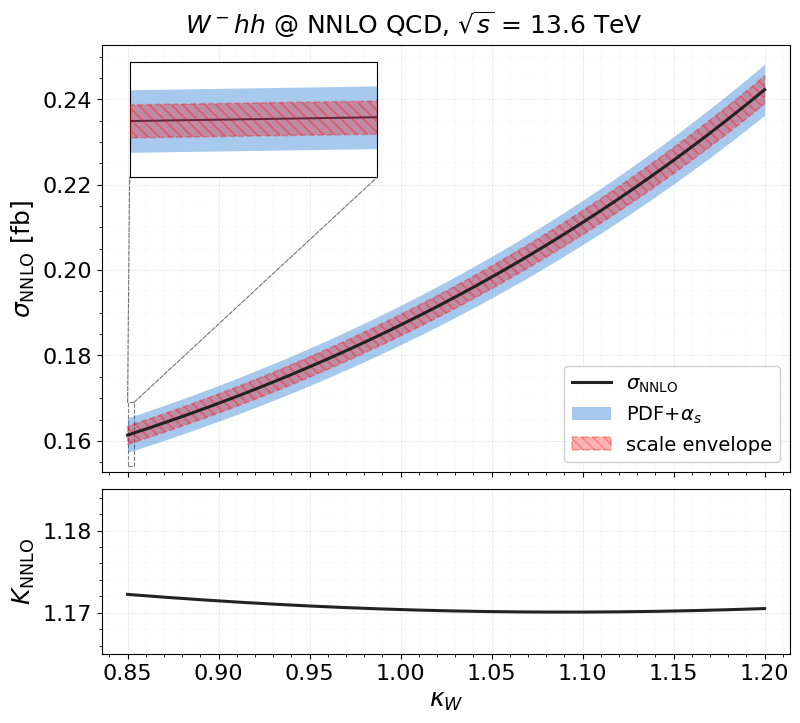

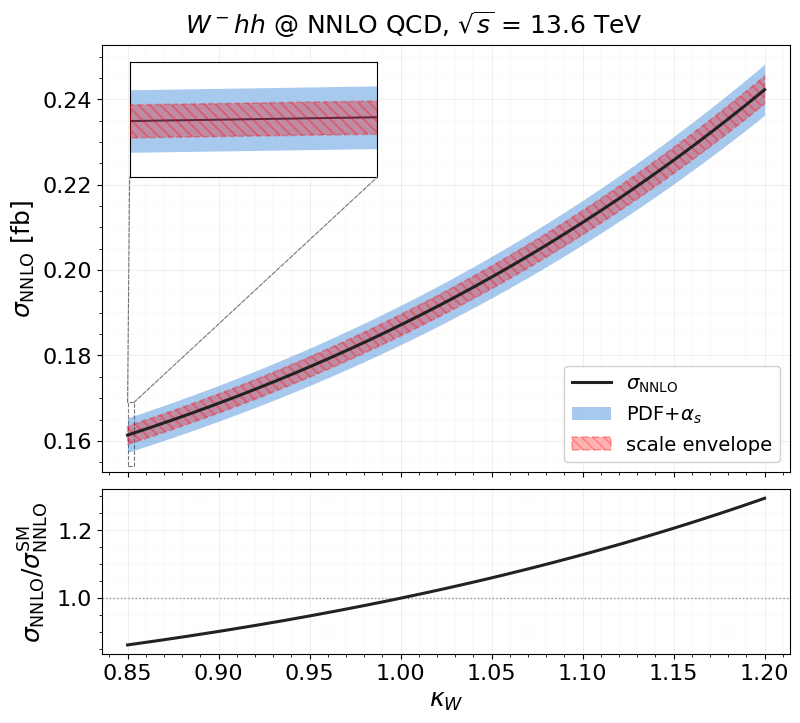

In [12]:
scan_axis = "kappa_w"
wilson_lo, wilson_hi = WILSON_INTERVALS[scan_axis]
scan_vmin, scan_vmax = wilson_lo, wilson_hi
scan_n_points = 400

print(f"Interval for {KAPPA_PLAIN[scan_axis]}: [{wilson_lo:g}, {wilson_hi:g}]")
print(f"Scan / plot window:                  [{scan_vmin:g}, {scan_vmax:g}]")

scan_data, scan_points_file = scan_and_save(
    analysis,
    scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    n_points=scan_n_points,
    uncertainties=True,
    save=SAVE_SCAN_POINTS,
)
if SAVE_SCAN_POINTS:
    print(f"Saved {scan_points_file}")

_, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
plot_title = default_plot_title(PROCESS, ENERGY_TEV, nn_label)
_nnlo_kw = dict(
    style=PLOT_STYLE,
    nnlo_label=nn_label,
    xmin=scan_vmin,
    xmax=scan_vmax,
    save=SAVE_PLOTS,
)

plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=plot_title,
    process=PROCESS,
    sigma_inset=SIGMA_INSET,
    output=scan_plot_path("HEFT", PROCESS, ENERGY_TEV, scan_x_key, scan_vmin, scan_vmax, "sigma_nnlo_K"),
    **_nnlo_kw,
)
plt.show()

plot_sigma_nnlo_and_enhancement_nnlo(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    show_enhancement_uncertainty=False,
    output=scan_plot_path("HEFT", PROCESS, ENERGY_TEV, scan_x_key, scan_vmin, scan_vmax, f"sigma_nnlo_sigmaSM_{nn_label}"),
    **_nnlo_kw,
)
plt.show()


## 4. Joint multi-axis scan (Cartesian grid)

Vary **all** listed $\kappa$ axes **at once** (Cartesian product) and write **one** `.txt` under `results/points/heft/<Process>/<energy>/`.
Non-scanned $\kappa$ stay at **SM** ($= 1$).

- `BATCH_SCAN_AXES` — axes to vary jointly
- `BATCH_SCAN_WINDOWS` — optional `{axis: (vmin, vmax)}`; omitted axes use `WILSON_INTERVALS`
- `BATCH_SCAN_N_POINTS` — points **per axis** (2 × 40 → 1600 rows)

Set `BATCH_SCAN_AXES = ()` to skip.


In [ ]:
BATCH_SCAN_AXES = (
    "kappa_lambda",
    "kappa_w",
)
BATCH_SCAN_N_POINTS = 40  # per axis → 40×40 = 1600 points for 2 axes
BATCH_SCAN_WINDOWS = {} # default use WILSON_INTERVALS

if BATCH_SCAN_AXES:
    scan_data, path = scan_grid_and_save(
        analysis,
        BATCH_SCAN_AXES,
        windows=BATCH_SCAN_WINDOWS or None,
        n_points=BATCH_SCAN_N_POINTS,
        save=SAVE_SCAN_POINTS,
        uncertainties=False,
    )
    n_total = len(next(iter(scan_data.values())))
    print(f"Joint grid scan: {len(BATCH_SCAN_AXES)} axes × {BATCH_SCAN_N_POINTS} pts → {n_total} points")
    for axis in BATCH_SCAN_AXES:
        x_key = resolve_scan_axis(PROCESS, axis)[1]
        lo, hi = (BATCH_SCAN_WINDOWS or {}).get(axis) or WILSON_INTERVALS[x_key]
        print(f"  {KAPPA_PLAIN[x_key]}  [{lo:g}, {hi:g}]")
    print(f"  →  {path if SAVE_SCAN_POINTS else '(not saved)'}")
else:
    print("Joint scan skipped (BATCH_SCAN_AXES is empty).")


Joint grid scan: 2 axes × 40 pts → 1600 points
  κ_λ  [-0.7, 6.1]
  κ_Z  [0.9, 1.2]
  →  /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/points/heft/ZHH/13_6TeV/ZHH_13.6TeV_kappa_lambda_x_kappa_z.txt


## 5. HEFT benchmark tables

σ tables cover **every** scan-axis $\kappa$ (`scan_axes(PROCESS)`):

| Channel | Groups (display only) | Keys |
|---------|----------------------|------|
| `WplusHH`, `WminusHH` | one table | `kappa_lambda`, `kappa_w`, `kappa_2w` |
| `ZHH` | group 1 | `kappa_lambda` ($\kappa_\lambda$), `kappa_t` ($\kappa_t$) |
| `ZHH` | group 2 | `kappa_z` ($\kappa_Z$), `kappa_2z` ($\kappa_{2Z}$) |

For each selected $\kappa$, σ is evaluated at SM and at that coefficient’s interval **min/max** (others held at SM $= 1$), for both 13.6 and 14 TeV. ZHH prints **one table per group**.

The LaTeX file `results/tables/heft/heft_publication_tables.tex` collects the same benchmark tables.

Grouping for ZHH is `ZHH_TABLE_GROUPS` in `vhh_predict/tables.py`; axes themselves come from `scan_axes`.


In [6]:
latex_path = heft_wilson_tables_path()

print("σ benchmark κ (all scan axes):")
for process in CHANNELS:
    axes = scan_axes(process)
    print(f"  {process}: {', '.join(axes)}")
for i, group in enumerate(ZHH_TABLE_GROUPS, start=1):
    print(f"  ZHH group {i}: keys={list(group)}")
    print(f"               symbols={', '.join(KAPPA_PLAIN[k] for k in group)}")

for process in CHANNELS:
    display(Markdown(f"## {process}"))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)
    if process == "ZHH":
        for axes in ZHH_TABLE_GROUPS:
            key = "_".join(axes)
            title = (
                f"({', '.join(axes)}) — "
                + ", ".join(KAPPA_PLAIN[a] for a in axes)
            )
            display(Markdown(f"### {title}"))
            display(tables[key])
    else:
        display(Markdown(f"### all scan axes ({', '.join(scan_axes(process))})"))
        display(tables)

latex_path.write_text(all_channels_latex(energies_tev=TABLE_ENERGIES_TEV), encoding="utf-8")
print(f"Saved {latex_path}")


σ benchmark κ (all scan axes):
  WplusHH: kappa_lambda, kappa_w, kappa_2w
  WminusHH: kappa_lambda, kappa_w, kappa_2w
  ZHH: kappa_lambda, kappa_z, kappa_2z, kappa_t
  ZHH group 1: keys=['kappa_lambda', 'kappa_t']
               symbols=κ_λ, κ_t
  ZHH group 2: keys=['kappa_z', 'kappa_2z']
               symbols=κ_Z, κ_2Z


## WplusHH

### all scan axes (kappa_lambda, kappa_w, kappa_2w)

,sqrt s [TeV],SM,κ_λ=-0.70,κ_λ=6.10,κ_W=0.85,κ_W=1.20,κ_2W=0.70,κ_2W=1.30
0,13.6,0.358 +0.36%/-0.40% ±2.3%,0.147 +0.30%/-0.42% ±2.4%,2.348 +0.40%/-0.41% ±2.2%,0.311 +0.34%/-0.40% ±2.3%,0.464 +0.36%/-0.40% ±2.3%,0.248 +0.37%/-0.40% ±2.2%,0.503 +0.34%/-0.40% ±2.3%
1,14.0,0.374 +0.37%/-0.40% ±2.2%,0.154 +0.30%/-0.41% ±2.4%,2.453 +0.41%/-0.40% ±2.2%,0.325 +0.35%/-0.40% ±2.3%,0.485 +0.37%/-0.40% ±2.2%,0.260 +0.38%/-0.40% ±2.2%,0.527 +0.35%/-0.40% ±2.3%


## WminusHH

...

### (kappa_lambda, kappa_t) — κ_λ, κ_t

,sqrt s [TeV],SM,κ_λ=-0.70,κ_λ=6.10,κ_t=0.80,κ_t=1.20
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.191 +6.70%/-5.15% ±1.9%,2.237 +1.50%/-1.26% ±2.0%,0.390 +3.04%/-2.40% ±1.9%,0.406 +3.97%/-3.09% ±1.9%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.203 +6.74%/-5.18% ±1.8%,2.348 +1.51%/-1.27% ±2.0%,0.411 +3.08%/-2.43% ±1.9%,0.428 +4.02%/-3.12% ±1.9%


### (kappa_z, kappa_2z) — κ_Z, κ_2Z

,sqrt s [TeV],SM,κ_Z=0.90,κ_Z=1.20,κ_2Z=0.70,κ_2Z=1.30
0,13.6,0.396 +3.39%/-2.66% ±1.9%,0.344 +2.83%/-2.25% ±2.0%,0.548 +4.44%/-3.44% ±1.9%,0.294 +4.53%/-3.50% ±1.8%,0.528 +2.58%/-2.07% ±2.0%
1,14.0,0.417 +3.42%/-2.69% ±1.9%,0.362 +2.86%/-2.27% ±1.9%,0.577 +4.49%/-3.47% ±1.8%,0.310 +4.57%/-3.54% ±1.8%,0.556 +2.60%/-2.09% ±2.0%


Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/tables/heft/heft_publication_tables.tex
